In [214]:
ls outs/umap

umap_2d_pure_bolt_nn100_md0d01_cosine.parquet
umap_2d_pure_bolt_nn100_md0d01_euclidean.parquet
umap_2d_pure_bolt_nn100_md0d1_cosine.parquet
umap_2d_pure_bolt_nn100_md0d1_euclidean.parquet
umap_2d_pure_bolt_nn100_md0d5_cosine.parquet
umap_2d_pure_bolt_nn100_md0d5_euclidean.parquet
umap_2d_pure_bolt_nn100_md1d0_cosine.parquet
umap_2d_pure_bolt_nn100_md1d0_euclidean.parquet
umap_2d_pure_bolt_nn10_md0d01_cosine.parquet
umap_2d_pure_bolt_nn10_md0d01_euclidean.parquet
umap_2d_pure_bolt_nn10_md0d1_cosine.parquet
umap_2d_pure_bolt_nn10_md0d1_euclidean.parquet
umap_2d_pure_bolt_nn10_md0d5_cosine.parquet
umap_2d_pure_bolt_nn10_md0d5_euclidean.parquet
umap_2d_pure_bolt_nn10_md1d0_cosine.parquet
umap_2d_pure_bolt_nn10_md1d0_euclidean.parquet
umap_2d_pure_bolt_nn50_md0d01_cosine.parquet
umap_2d_pure_bolt_nn50_md0d01_euclidean.parquet
umap_2d_pure_bolt_nn50_md0d1_cosine.parquet
umap_2d_pure_bolt_nn50_md0d1_euclidean.parquet
umap_2d_pure_bolt_nn50_md0d5_cosine.parquet
umap_2d_pure_bolt_nn50_md0d5_euc

In [216]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

OUTS = Path("outs/umap")
FILE = "umap_2d_pure_bolt_nn50_md0d1_cosine.parquet"
BINS = 1000
GAMMA = 0.3

In [217]:
df = pd.read_parquet(OUTS / FILE, columns=["umap_x", "umap_y"])
print(f"{len(df):,} points")

5,412,049 points


In [218]:
x = df["umap_x"].to_numpy()
y = df["umap_y"].to_numpy()

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

xi = np.clip(((x - x_min) / (x_max - x_min) * BINS).astype(np.int32), 0, BINS - 1)
yi = np.clip(((y - y_min) / (y_max - y_min) * BINS).astype(np.int32), 0, BINS - 1)

heatmap = np.bincount(yi * BINS + xi, minlength=BINS * BINS).reshape(BINS, BINS)

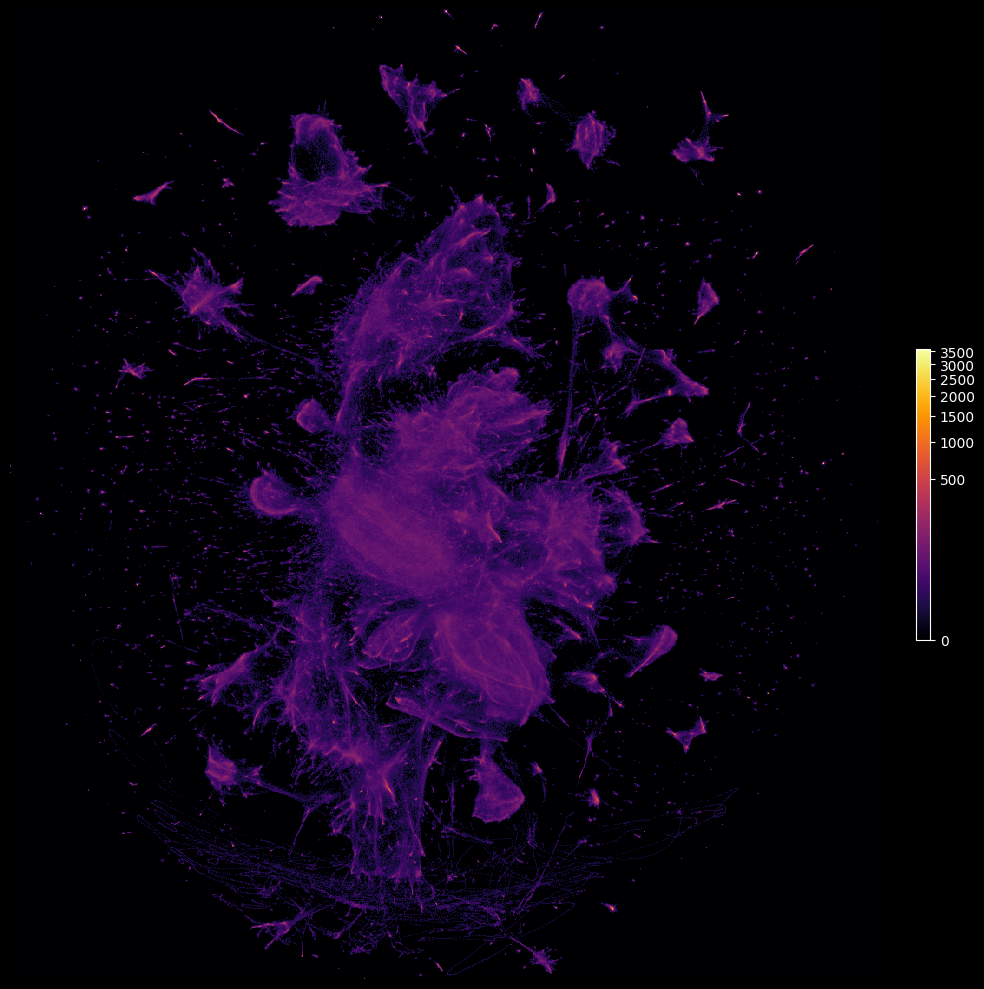

In [219]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(
        heatmap,
        origin="lower",
        norm=PowerNorm(gamma=GAMMA, vmin=0., vmax=heatmap.max()),
        cmap="inferno",
        interpolation="nearest",
        extent=[x_min, x_max, y_min, y_max],
        aspect="auto",
    )
    fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.3, pad=0.04)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()